# Wide and Deep Neural Network
### by Pooya Valizadeh

what are Wide and Deep Neural networks???

Wide & Deep Neural Networks are a type of neural network architecture introduced by Google in 2016 that combines two different types of learning into one model:

Wide part → Learns memorization (remembers specific patterns/examples)

Deep part → Learns generalization (understands new, unseen patterns)

In [73]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

import warnings
warnings.filterwarnings("ignore")

In [74]:
from sklearn.datasets import fetch_california_housing as data
data()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

## preprocessing

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


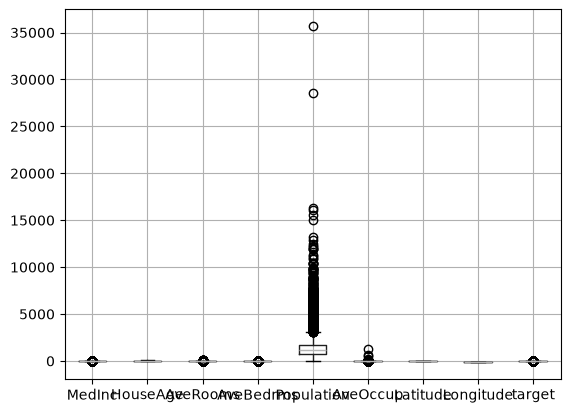

In [75]:
df = pd.DataFrame(data().data, columns=data().feature_names)
df['target'] = data().target

print(df.head())
df.boxplot()
plt.show()

In [76]:

df = df[(df < 12000).all(axis=1)]
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


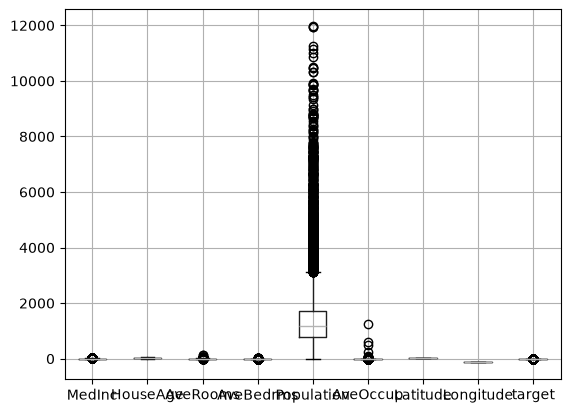

In [77]:
df.boxplot()
plt.show()

In [78]:
x = df.drop(columns="target").values
y = df["target"].values

In [79]:
from sklearn.model_selection import train_test_split as tts 
xtrain , xtest , ytrain , ytest = tts(x,y,random_state=26,test_size=0.2)

In [80]:
print(xtrain.shape , ytrain.shape , xtest.shape , ytest.shape)

(16503, 8) (16503,) (4126, 8) (4126,)


In [81]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
xtrain = scale.fit_transform(xtrain)
xtest = scale.transform(xtest)

## bulding the model

In [82]:
from tensorflow.keras.layers import concatenate , Input , Dense

In [83]:
x.shape

(20629, 8)

In [84]:
input_ = Input(shape = (8,))
h1 = Dense(60,activation="relu")(input_)
h2 = Dense(10,activation="relu")(h1)
h3 = concatenate([input_,h2])
output = Dense(1,name="output")(h3)
output2 = Dense(1,name="output2")(h3)
model = keras.Model(input_,[output,output2])

In [85]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 60)        │        540 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10)        │        610 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 18)        │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         19 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output2 (Dense)     │ (None, 1)         │         19 │ concatenate_4[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,188 (4.64 KB)

 Trainable params: 1,188 (4.64 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(loss= [keras.losses.MeanSquaredError(),keras.losses.MeanAbsoluteError()],optimizer= "Adam",metrics=[keras.metrics.MeanSquaredError(),keras.metrics.MeanSquaredError()])

## training the model

In [87]:
saveing_fit = keras.callbacks.ModelCheckpoint("model_best.keras",save_best_only=True)
early_fit = keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)

In [88]:
history = model.fit(xtrain,[ytrain,ytrain],epochs=150,batch_size=100,validation_split=0.2,callbacks=[saveing_fit,early_fit])

Epoch 1/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.2390 - output2_loss: 1.5861 - output2_mean_squared_error: 4.5881 - output_loss: 1.6506 - output_mean_squared_error: 1.6494 - val_loss: 1.7295 - val_output2_loss: 0.8695 - val_output2_mean_squared_error: 3.2292 - val_output_loss: 0.8247 - val_output_mean_squared_error: 0.8472
Epoch 2/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3398 - output2_loss: 0.6664 - output2_mean_squared_error: 0.9555 - output_loss: 0.6660 - output_mean_squared_error: 0.6706 - val_loss: 1.1855 - val_output2_loss: 0.5901 - val_output2_mean_squared_error: 1.8051 - val_output_loss: 0.5651 - val_output_mean_squared_error: 0.5820
Epoch 3/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0777 - output2_loss: 0.5479 - output2_mean_squared_error: 0.6685 - output_loss: 0.5233 - output_mean_squared_error: 0.5268 - val_loss: 0.9852 - val_output2_loss: 0.5164 - val_output2_mean_squared_error: 1.1345 - val_output_loss: 0.4461 - val_output_mean_squar

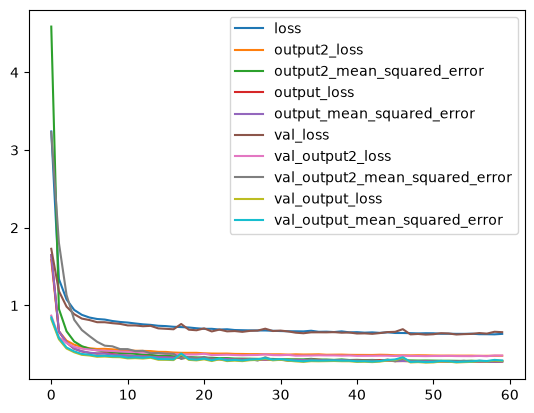

In [89]:
pd.DataFrame(history.history).plot()
plt.show()

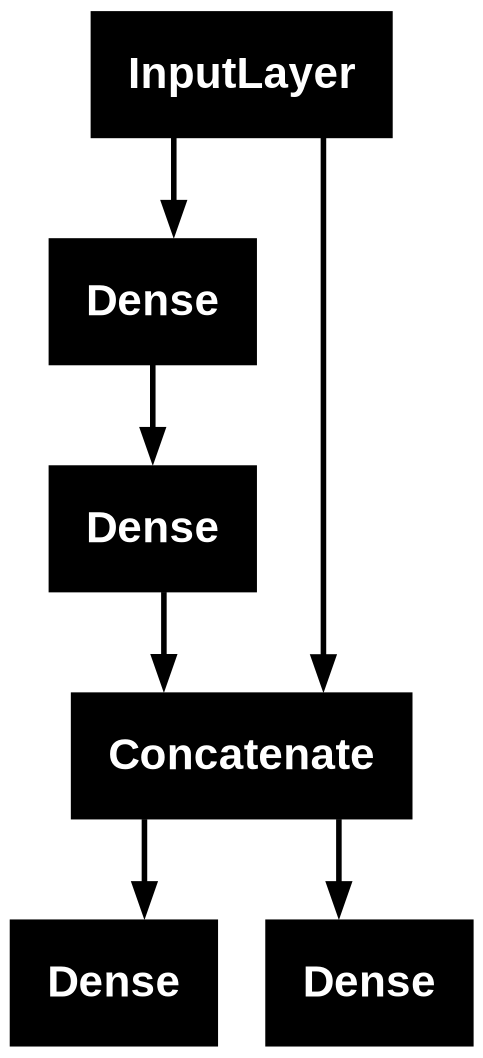

In [90]:
keras.utils.plot_model(model)

## evaluate

In [91]:
model.evaluate(xtest,[ytest,ytest],verbose=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6492 - output2_loss: 0.3594 - output2_mean_squared_error: 0.2930 - output_loss: 0.2898 - output_mean_squared_error: 0.2898


[0.6491734981536865,
 0.2898124158382416,
 0.3594038486480713,
 0.29297226667404175,
 0.2897893488407135]